In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../data/processed/data_preprocessed.csv",encoding='latin-1')
data.head()

,Unnamed: 0,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,...,RajastÃ¡n,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,...,RajastÃ¡n,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
df = data[
    [
        'Customer Id',
        'Order Id',
        'Sales',
        'order date (DateOrders)',
        'Department Name',
        'Order Item Discount',
        'Order Profit Per Order',
        'Order Item Discount Rate'
    ]
]
df

,Customer Id,Order Id,Sales,order date (DateOrders),Department Name,Order Item Discount,Order Profit Per Order,Order Item Discount Rate
0,20755,77202,327.750000,1/31/2018 22:56,Fitness,13.110000,91.250000,0.04
1,19492,75939,327.750000,1/13/2018 12:27,Fitness,16.389999,-249.089996,0.05
2,19491,75938,327.750000,1/13/2018 12:06,Fitness,18.030001,-247.779999,0.06
3,19490,75937,327.750000,1/13/2018 11:45,Fitness,22.940001,22.860001,0.07
4,19489,75936,327.750000,1/13/2018 11:24,Fitness,29.500000,134.210007,0.09
...,...,...,...,...,...,...,...,...
180514,1005,26043,399.980011,1/16/2016 3:40,Fan Shop,0.000000,40.000000,0.00
180515,9141,26037,399.980011,1/16/2016 1:34,Fan Shop,4.000000,-613.770019,0.01
180516,291,26024,399.980011,1/15/2016 21:00,Fan Shop,8.000000,141.110001,0.02
180517,2813,26022,399.980011,1/15/2016 20:18,Fan Shop,12.000000,186.229996,0.03


Creating Recency, Frequency and Monetary(RFM)

In [4]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
snapshot_date = (df['order date (DateOrders)'].max()+ pd.Timedelta(days=1))
rfm = (df.groupby('Customer Id').agg({'order date (DateOrders)': lambda x:(snapshot_date - x.max()).days,
                                      'Order Id': 'nunique',
                                      'Sales': 'sum'}).reset_index())
rfm.columns = ['Customer Id','Recency','Frequency','Monetary']
rfm

,Customer Id,Recency,Frequency,Monetary
0,1,793,1,499.950012
1,2,137,4,1819.730034
2,3,230,5,3537.680094
3,4,381,4,1719.630030
4,5,458,3,1274.750023
...,...,...,...,...
20647,20753,1,1,215.820007
20648,20754,1,1,215.820007
20649,20755,1,1,327.750000
20650,20756,1,1,11.540000


Average Order Value

In [5]:
rfm['Avg_Order_Value']=rfm['Monetary']/rfm['Frequency']

Product Category Diversity

In [6]:
category_diversity = (df.groupby("Customer Id")["Department Name"].nunique())
rfm['Unique_Product_Categories']=category_diversity
rfm.head()

,Customer Id,Recency,Frequency,Monetary,Avg_Order_Value,Unique_Product_Categories
0,1,793,1,499.950012,499.950012,NaN
1,2,137,4,1819.730034,454.932508,1.0
2,3,230,5,3537.680094,707.536019,3.0
3,4,381,4,1719.630030,429.907507,4.0
4,5,458,3,1274.750023,424.916674,4.0


Discount Behavior

In [7]:
# Average discount rate per customer
avg_discount_rate = (df.groupby("Customer Id")["Order Item Discount Rate"].mean())
rfm['Avg_Discount_Rate']=round(avg_discount_rate,2)
rfm.head()

,Customer Id,Recency,Frequency,Monetary,Avg_Order_Value,Unique_Product_Categories,Avg_Discount_Rate
0,1,793,1,499.950012,499.950012,NaN,NaN
1,2,137,4,1819.730034,454.932508,1.0,0.06
2,3,230,5,3537.680094,707.536019,3.0,0.13
3,4,381,4,1719.630030,429.907507,4.0,0.11
4,5,458,3,1274.750023,424.916674,4.0,0.14


Total Profitability

In [8]:
total_profit = (df.groupby("Customer Id")["Order Profit Per Order"].sum())
rfm['Total_Profit']=total_profit

Convert to RFM Scores (1–5)

In [9]:
# We don't compare raw values (Instead we rank customers).
rfm['R_Score'] = pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])

rfm['RFM_Total'] = (
    rfm['R_Score'].astype(int)
    + rfm['F_Score'].astype(int)
    + rfm['M_Score'].astype(int)
)

rfm[['R_Score','F_Score','M_Score']].describe()

rfm.head()

,Customer Id,Recency,Frequency,Monetary,Avg_Order_Value,Unique_Product_Categories,Avg_Discount_Rate,Total_Profit,R_Score,F_Score,M_Score,RFM_Total
0,1,793,1,499.950012,499.950012,NaN,NaN,NaN,1,1,2,4
1,2,137,4,1819.730034,454.932508,1.0,0.06,159.690002,3,3,3,9
2,3,230,5,3537.680094,707.536019,3.0,0.13,208.739999,2,4,5,11
3,4,381,4,1719.630030,429.907507,4.0,0.11,334.489999,1,3,3,7
4,5,458,3,1274.750023,424.916674,4.0,0.14,-439.979992,1,3,3,7


Customer Segments

In [10]:
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost Customers'
rfm['Customer Segment'] = rfm['RFM_Total'].apply(segment_customer)

In [11]:
rfm.to_csv("rfm data/rfm.csv", index=False)

In [12]:
rfm['Customer Segment'].value_counts()

Customer Segment
Potential Loyalists    11768
Loyal Customers         5803
At Risk                 1511
Champions               1493
Lost Customers            77
Name: count, dtype: int64

Customer Segment Distribution ⭐

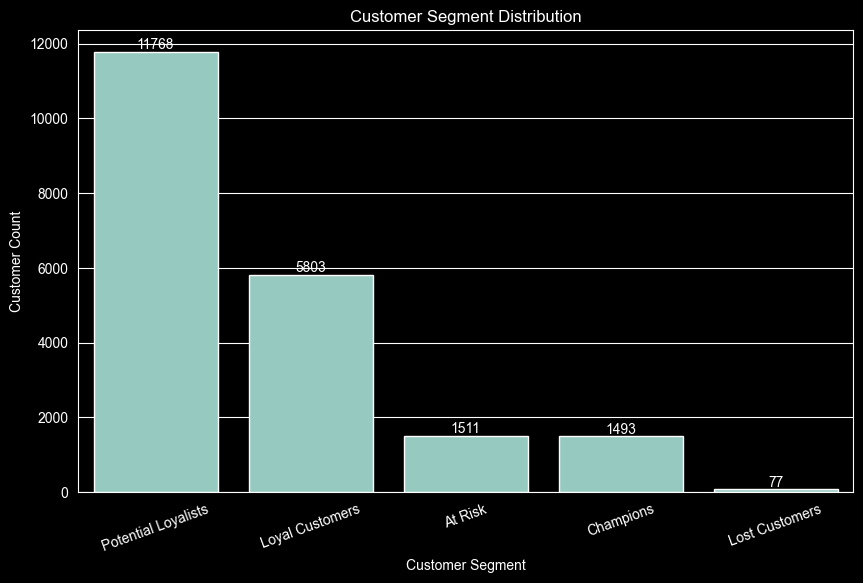

In [13]:
segment_count = (rfm['Customer Segment'].value_counts().reset_index())

segment_count.columns = ['Customer Segment','Customer Count']
plt.figure(figsize=(10,6))

ax = sns.barplot(data=segment_count,x='Customer Segment',y='Customer Count')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Customer Segment Distribution')
plt.xticks(rotation=20)
plt.show()

KPI Cards

In [14]:
total_customers = rfm['Customer Id'].nunique()
avg_recency = rfm['Recency'].mean()
avg_frequency = rfm['Frequency'].mean()
avg_monetary = rfm['Monetary'].mean()

print(f"Total Customers: {total_customers:,}")
print(f"Average Recency: {avg_recency:.0f}")
print(f"Average Frequency: {avg_frequency:.2f}")
print(f"Average Monetary Value: {avg_monetary:.2f}")

Total Customers: 20,652
Average Recency: 221
Average Frequency: 3.18
Average Monetary Value: 1781.17


Recency Distribution

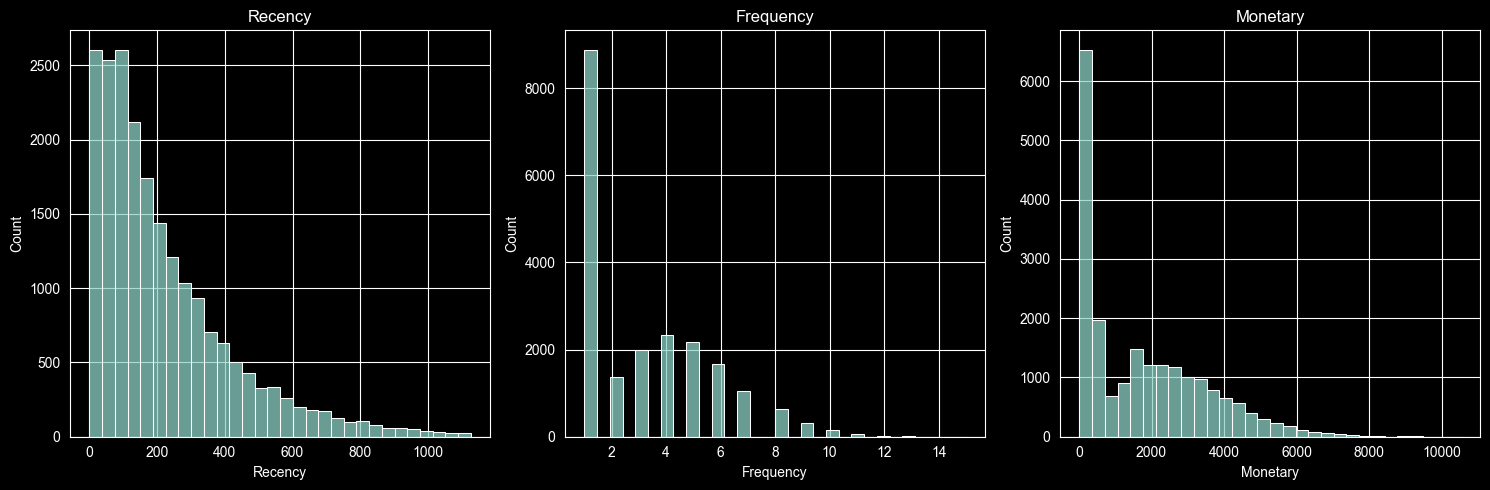

In [15]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], bins=30)
plt.title('Recency')

plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], bins=30)
plt.title('Frequency')

plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], bins=30)
plt.title('Monetary')

plt.tight_layout()
plt.show()

Revenue Contribution by Segment ⭐

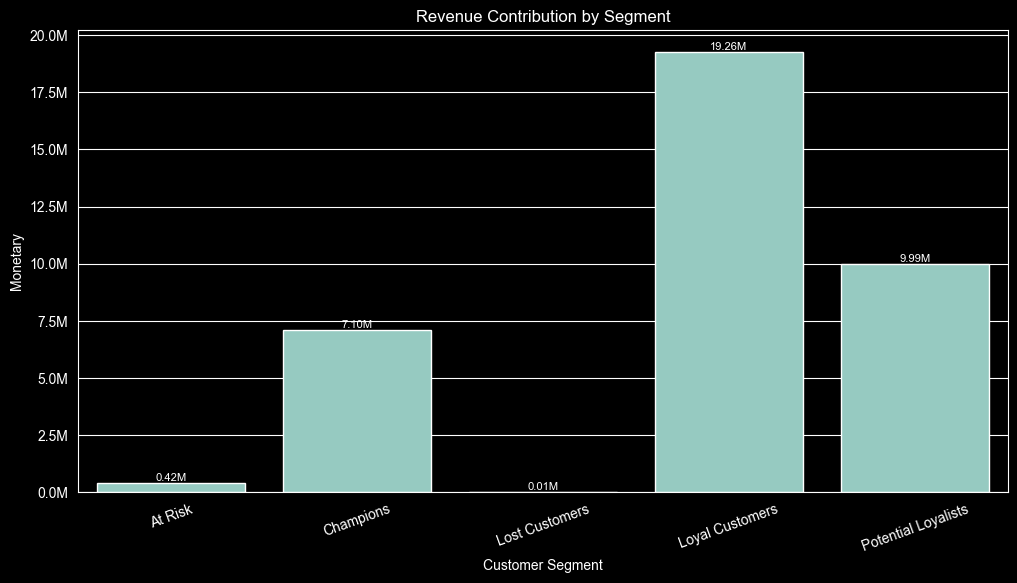

In [16]:
import matplotlib.ticker as ticker
rev_contribution=rfm.groupby('Customer Segment')['Monetary'].sum()
plt.figure(figsize=(12,6))

ax = sns.barplot(rev_contribution)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1000000:.2f}M' for v in container.datavalues],
        fontsize=8)

plt.title('Revenue Contribution by Segment')
plt.xticks(rotation=20)
plt.show()

Recency vs Monetary

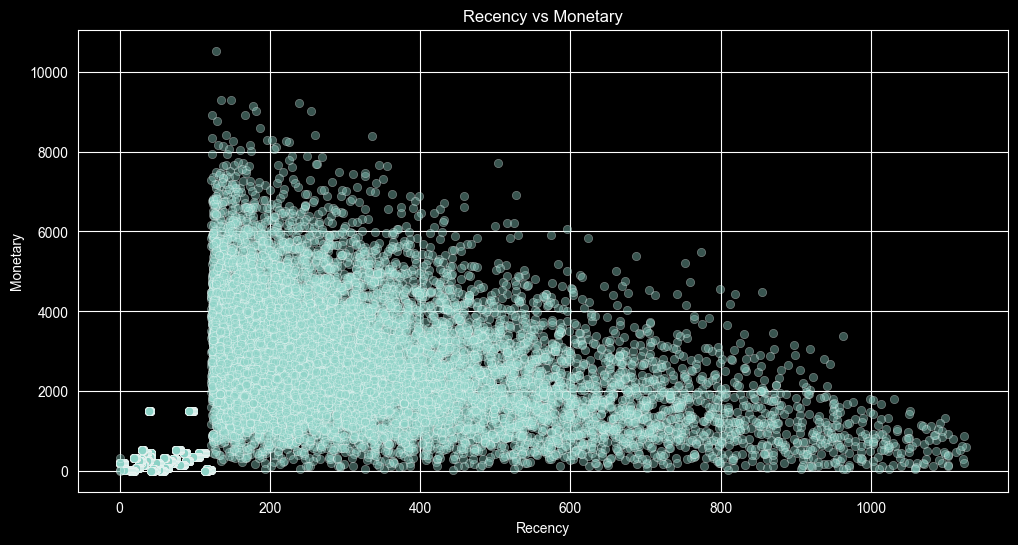

In [17]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=rfm,x='Recency',y='Monetary',alpha=0.4)
plt.title('Recency vs Monetary')
plt.show()

Frequency vs Monetary ⭐

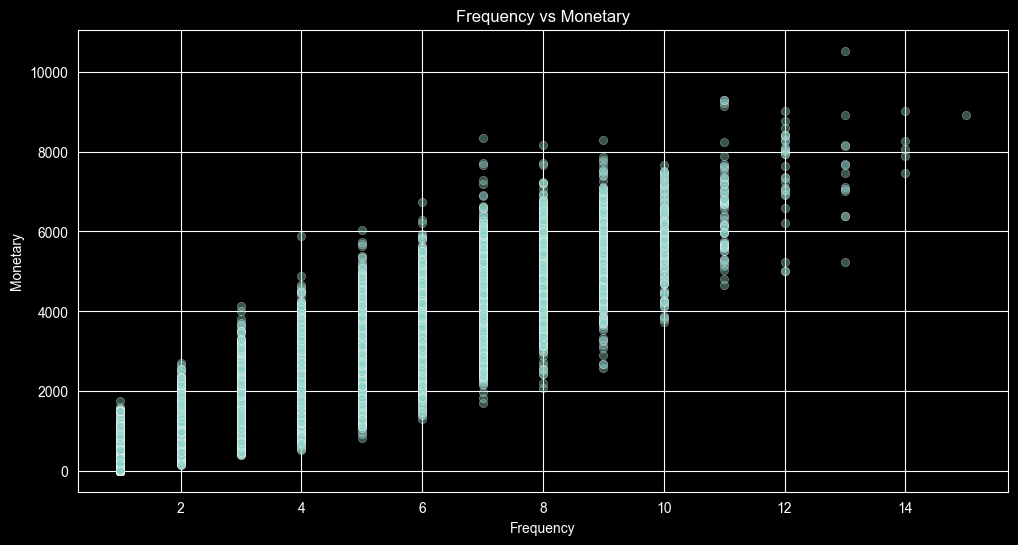

In [18]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=rfm,x='Frequency',y='Monetary',alpha=0.4)
plt.title('Frequency vs Monetary')
plt.show()

Top 10 Customers by Revenue

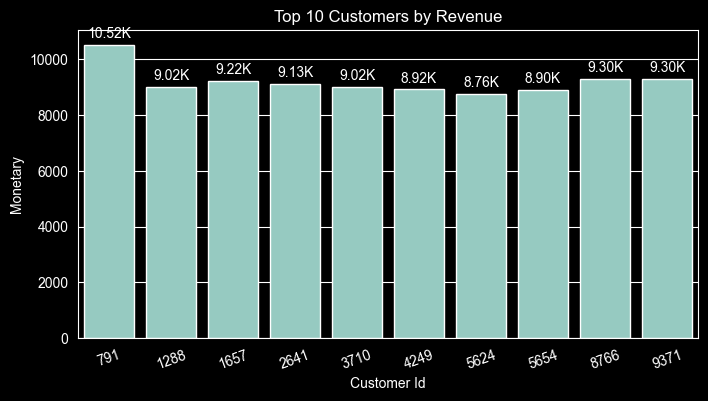

In [19]:
import matplotlib.ticker as ticker
rev_contribution=rfm.groupby('Customer Id')['Monetary'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
ax = sns.barplot(rev_contribution)
for container in ax.containers:
    ax.bar_label(container,labels=[f'{v/1000:.2f}K' for v in container.datavalues],padding=3)
plt.title('Top 10 Customers by Revenue')
plt.xticks(rotation=20)
plt.show()

Top 10 Customers by Frequency

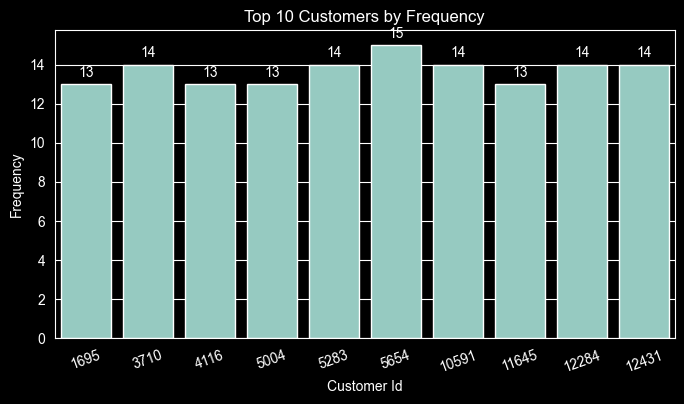

In [20]:
import matplotlib.ticker as ticker
rev_contribution=rfm.groupby('Customer Id')['Frequency'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
ax = sns.barplot(rev_contribution)
for container in ax.containers:
    ax.bar_label(container,fmt='%d',padding=3)
plt.title('Top 10 Customers by Frequency')
plt.xticks(rotation=20)
plt.show()

RFM Heatmap ⭐

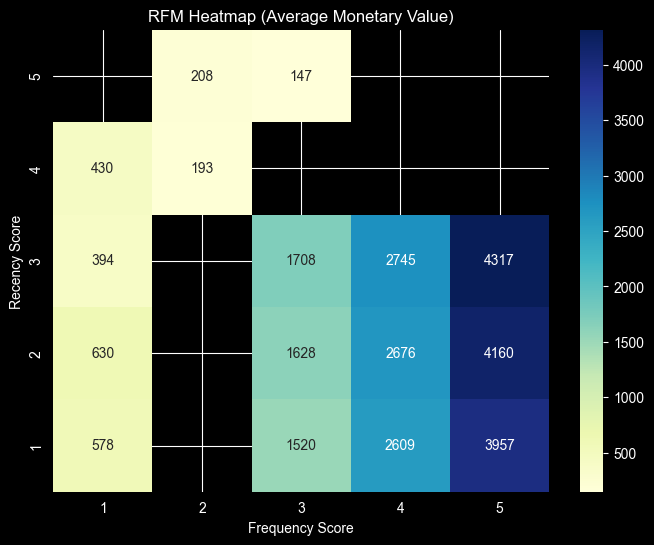

In [21]:
heatmap_data = rfm.pivot_table(values='Monetary',index='R_Score',columns='F_Score',aggfunc='mean')
plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data,annot=True,fmt='.0f',cmap='YlGnBu')
plt.title('RFM Heatmap (Average Monetary Value)')
plt.xlabel('Frequency Score')
plt.ylabel('Recency Score')
plt.show()